In [2]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Infosys data fetch karo
ticker = yf.Ticker("INFY")

# Financial statements
income_stmt = ticker.financials
balance_sheet = ticker.balance_sheet
cash_flow = ticker.cashflow

# Current stock price
current_price = ticker.info['currentPrice']
print(f"Current Price: ${current_price}")

print("\nIncome Statement rows:")
print(income_stmt.index.tolist())

print("\nCash Flow rows:")
print(cash_flow.index.tolist())

Current Price: $12.09

Income Statement rows:
['Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Normalized EBITDA', 'Total Unusual Items', 'Total Unusual Items Excluding Goodwill', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA', 'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Total Expenses', 'Rent Expense Supplemental', 'Total Operating Income As Reported', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Net Income Common Stockholders', 'Net Income', 'Minority Interests', 'Net Income Including Noncontrolling Interests', 'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income', 'Other Income Expense', 'Other Non Operating Income Expenses', 'Special Income Charges', 'Write Off', 'Gain On Sale Of Security', 'Net Non Operati

In [4]:
# Revenue (last 4 years)
revenue = income_stmt.loc['Total Revenue']
print("Revenue (last 4 years):")
print(revenue)

# Operating Cash Flow
ocf = cash_flow.loc['Operating Cash Flow']
print("\nOperating Cash Flow:")
print(ocf)

# Capital Expenditure (CapEx)
capex = cash_flow.loc['Capital Expenditure']
print("\nCapEx:")
print(capex)

# Free Cash Flow = OCF - CapEx
fcf = ocf + capex  # CapEx already negative in Yahoo Finance
print("\nFree Cash Flow (FCF):")
print(fcf)

# Net Income
net_income = income_stmt.loc['Net Income']
print("\nNet Income:")
print(net_income)

Revenue (last 4 years):
2026-03-31    2.015800e+10
2025-03-31    1.927700e+10
2024-03-31    1.856200e+10
2023-03-31    1.821200e+10
2022-03-31             NaN
Name: Total Revenue, dtype: float64

Operating Cash Flow:
2026-03-31    4.039000e+09
2025-03-31    4.351000e+09
2024-03-31    3.148000e+09
2023-03-31    2.853000e+09
2022-03-31             NaN
Name: Operating Cash Flow, dtype: float64

CapEx:
2026-03-31   -306000000.0
2025-03-31   -263000000.0
2024-03-31   -266000000.0
2023-03-31   -319000000.0
2022-03-31            NaN
Name: Capital Expenditure, dtype: float64

Free Cash Flow (FCF):
2026-03-31    3.733000e+09
2025-03-31    4.088000e+09
2024-03-31    2.882000e+09
2023-03-31    2.534000e+09
2022-03-31             NaN
dtype: float64

Net Income:
2026-03-31    3.313000e+09
2025-03-31    3.158000e+09
2024-03-31    3.167000e+09
2023-03-31    2.981000e+09
2022-03-31             NaN
Name: Net Income, dtype: float64


In [5]:
# Sort by date (oldest to newest)
fcf = fcf.dropna().sort_index()
revenue = revenue.dropna().sort_index()

# Revenue Growth Rate (Year over Year)
rev_growth = revenue.pct_change().dropna()
print("Revenue Growth Rates (YoY):")
print(rev_growth)

avg_growth = rev_growth.mean()
print(f"\nAverage Revenue Growth Rate: {avg_growth:.2%}")

# FCF Growth Rate
fcf_growth = fcf.pct_change().dropna()
avg_fcf_growth = fcf_growth.mean()
print(f"Average FCF Growth Rate: {avg_fcf_growth:.2%}")

# WACC — manually set karte hain (industry standard for IT services)
# Components:
# Risk Free Rate (India 10-yr bond) = 7%
# Beta (INFY) = ~0.7
# Equity Risk Premium = 5%
# Cost of Equity = 7% + 0.7 * 5% = 10.5%
# INFY debt is minimal — WACC ~ Cost of Equity
wacc = 0.105  # 10.5%
print(f"\nWACC (assumed): {wacc:.2%}")

# Terminal Growth Rate (long-term GDP growth rate)
terminal_growth = 0.03  # 3%
print(f"Terminal Growth Rate: {terminal_growth:.2%}")

Revenue Growth Rates (YoY):
2024-03-31    0.019218
2025-03-31    0.038520
2026-03-31    0.045702
Name: Total Revenue, dtype: float64

Average Revenue Growth Rate: 3.45%
Average FCF Growth Rate: 15.63%

WACC (assumed): 10.50%
Terminal Growth Rate: 3.00%


In [6]:
# Base FCF (most recent year)
base_fcf = fcf.iloc[-1]
print(f"Base FCF (2026): ${base_fcf/1e9:.2f}B")

# FCF growth rate use karenge — but conservative rakho
# Average FCF growth 15.63% hai but revenue growth sirf 3.45%
# FCF growth itna high sustainable nahi — conservative estimate use karo
projection_growth = 0.08  # 8% — between revenue and FCF growth
print(f"Projection Growth Rate (conservative): {projection_growth:.2%}")

# Project FCF for next 5 years
projected_fcf = []
for year in range(1, 6):
    projected = base_fcf * (1 + projection_growth) ** year
    projected_fcf.append(projected)
    print(f"Year {year} FCF: ${projected/1e9:.2f}B")

# Discount each year's FCF to present value
pv_fcf = []
for i, cf in enumerate(projected_fcf):
    pv = cf / (1 + wacc) ** (i + 1)
    pv_fcf.append(pv)
    print(f"Year {i+1} PV: ${pv/1e9:.2f}B")

total_pv_fcf = sum(pv_fcf)
print(f"\nTotal PV of FCF (5 years): ${total_pv_fcf/1e9:.2f}B")

Base FCF (2026): $3.73B
Projection Growth Rate (conservative): 8.00%
Year 1 FCF: $4.03B
Year 2 FCF: $4.35B
Year 3 FCF: $4.70B
Year 4 FCF: $5.08B
Year 5 FCF: $5.49B
Year 1 PV: $3.65B
Year 2 PV: $3.57B
Year 3 PV: $3.49B
Year 4 PV: $3.41B
Year 5 PV: $3.33B

Total PV of FCF (5 years): $17.44B


In [7]:
# Terminal Value — Year 5 ke baad infinite growth assume karte hain
# Formula: TV = FCF_year5 * (1 + terminal_growth) / (WACC - terminal_growth)
terminal_value = projected_fcf[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
print(f"Terminal Value: ${terminal_value/1e9:.2f}B")

# Terminal Value ko bhi discount karo (5 saal ke liye)
pv_terminal_value = terminal_value / (1 + wacc) ** 5
print(f"PV of Terminal Value: ${pv_terminal_value/1e9:.2f}B")

# Total Enterprise Value
enterprise_value = total_pv_fcf + pv_terminal_value
print(f"\nEnterprise Value: ${enterprise_value/1e9:.2f}B")

# Shares outstanding
shares = ticker.info['sharesOutstanding']
print(f"Shares Outstanding: {shares/1e9:.2f}B")

# Intrinsic Value per share
intrinsic_value = enterprise_value / shares
print(f"\nIntrinsic Value per Share: ${intrinsic_value:.2f}")
print(f"Current Market Price:      ${current_price:.2f}")

# Upside/Downside
upside = (intrinsic_value - current_price) / current_price * 100
if upside > 0:
    print(f"\nStock is UNDERVALUED by {upside:.1f}% → Potential BUY")
else:
    print(f"\nStock is OVERVALUED by {abs(upside):.1f}% → Potential SELL/HOLD")

Terminal Value: $75.33B
PV of Terminal Value: $45.72B

Enterprise Value: $63.16B
Shares Outstanding: 4.05B

Intrinsic Value per Share: $15.59
Current Market Price:      $12.09

Stock is UNDERVALUED by 29.0% → Potential BUY


Sensitivity Analysis — Intrinsic Value per Share ($):
2.0% g   [np.float64(18.68), np.float64(16.12), np.float64(14.17), np.float64(12.63), np.float64(11.38)]
2.5% g   [np.float64(19.93), np.float64(17.02), np.float64(14.84), np.float64(13.14), np.float64(11.79)]
3.0% g   [np.float64(21.41), np.float64(18.05), np.float64(15.59), np.float64(13.71), np.float64(12.23)]
3.5% g   [np.float64(23.19), np.float64(19.26), np.float64(16.46), np.float64(14.36), np.float64(12.73)]
4.0% g   [np.float64(25.36), np.float64(20.69), np.float64(17.46), np.float64(15.09), np.float64(13.28)]


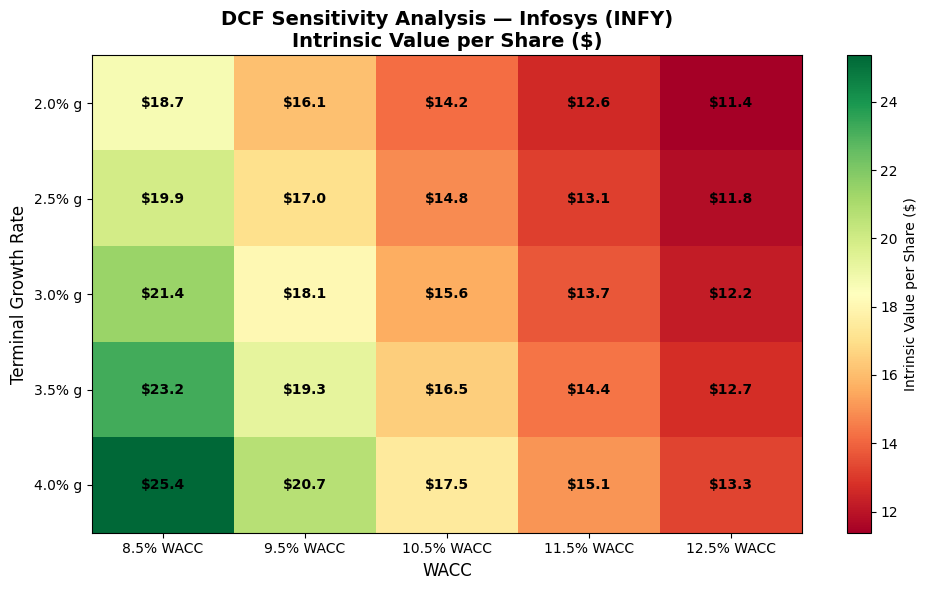

Heatmap saved!


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# WACC aur Growth Rate ke different combinations
wacc_range = [0.085, 0.095, 0.105, 0.115, 0.125]
growth_range = [0.02, 0.025, 0.03, 0.035, 0.04]

# Intrinsic value matrix banao
sensitivity_matrix = []

for tg in growth_range:
    row = []
    for w in wacc_range:
        tv = projected_fcf[-1] * (1 + tg) / (w - tg)
        pv_tv = tv / (1 + w) ** 5
        pv_fcfs = sum([projected_fcf[i] / (1 + w) ** (i+1) for i in range(5)])
        ev = pv_fcfs + pv_tv
        iv = ev / shares
        row.append(round(iv, 2))
    sensitivity_matrix.append(row)

print("Sensitivity Analysis — Intrinsic Value per Share ($):")
wacc_labels = [f"{w:.1%}" for w in wacc_range]
growth_labels = [f"{g:.1%} g" for g in growth_range]
for i, row in enumerate(sensitivity_matrix):
    print(f"{growth_labels[i]:8s}", row)

# Matplotlib heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(sensitivity_matrix, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Intrinsic Value per Share ($)')

ax.set_xticks(range(len(wacc_range)))
ax.set_yticks(range(len(growth_range)))
ax.set_xticklabels([f"{w:.1%} WACC" for w in wacc_range])
ax.set_yticklabels([f"{g:.1%} g" for g in growth_range])

# Values annotate karo
for i in range(len(growth_range)):
    for j in range(len(wacc_range)):
        ax.text(j, i, f"${sensitivity_matrix[i][j]:.1f}",
                ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("WACC", fontsize=12)
ax.set_ylabel("Terminal Growth Rate", fontsize=12)
ax.set_title("DCF Sensitivity Analysis — Infosys (INFY)\nIntrinsic Value per Share ($)",
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("dcf_sensitivity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

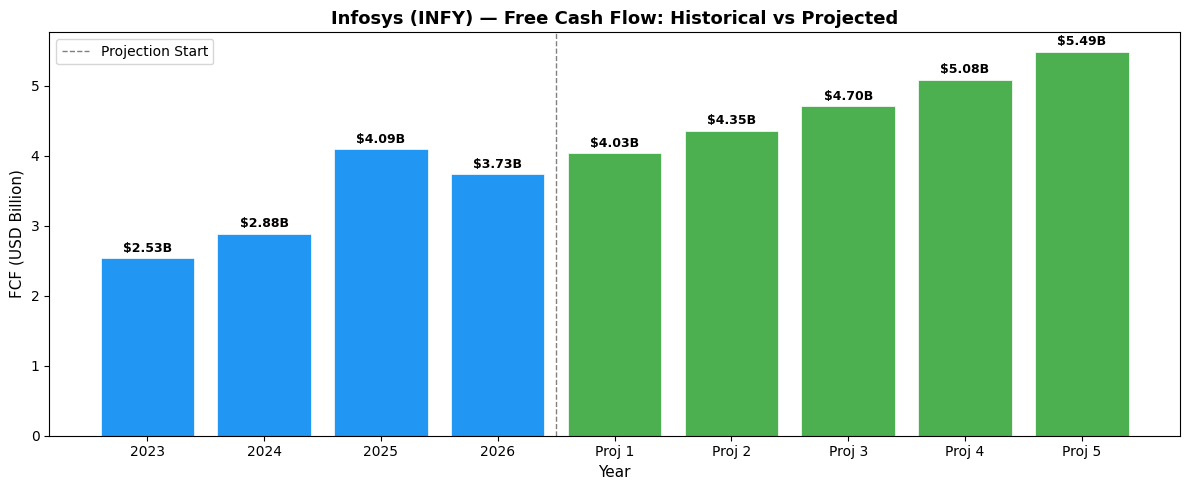

       DCF VALUATION SUMMARY — INFY
  Current Market Price  : $12.09
  Intrinsic Value       : $15.59
  Upside Potential      : 29.0%
  Enterprise Value      : $63.16B
  PV of 5-yr FCFs       : $17.44B
  PV of Terminal Value  : $45.72B
  WACC Used             : 10.50%
  FCF Growth Rate       : 8.00%
  Terminal Growth Rate  : 3.00%
  Verdict: UNDERVALUED — Potential BUY Signal


In [10]:
# Chart 1 — FCF Projection
years = ['2023', '2024', '2025', '2026', 'Proj 1', 'Proj 2', 'Proj 3', 'Proj 4', 'Proj 5']
fcf_values = list(fcf.values / 1e9) + [x / 1e9 for x in projected_fcf]

colors = ['#2196F3'] * 4 + ['#4CAF50'] * 5  # Blue = historical, Green = projected

plt.figure(figsize=(12, 5))
bars = plt.bar(years, fcf_values, color=colors, edgecolor='white', linewidth=0.5)

# Value labels on bars
for bar, val in zip(bars, fcf_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${val:.2f}B', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.axvline(x=3.5, color='gray', linestyle='--', linewidth=1, label='Projection Start')
plt.title('Infosys (INFY) — Free Cash Flow: Historical vs Projected',
          fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('FCF (USD Billion)', fontsize=11)
plt.legend(['Projection Start'], fontsize=10)
plt.tight_layout()
plt.savefig("dcf_fcf_projection.png", dpi=150, bbox_inches='tight')
plt.show()

# Final Summary
print("=" * 50)
print("       DCF VALUATION SUMMARY — INFY")
print("=" * 50)
print(f"  Current Market Price  : ${current_price:.2f}")
print(f"  Intrinsic Value       : ${intrinsic_value:.2f}")
print(f"  Upside Potential      : {upside:.1f}%")
print(f"  Enterprise Value      : ${enterprise_value/1e9:.2f}B")
print(f"  PV of 5-yr FCFs       : ${total_pv_fcf/1e9:.2f}B")
print(f"  PV of Terminal Value  : ${pv_terminal_value/1e9:.2f}B")
print(f"  WACC Used             : {wacc:.2%}")
print(f"  FCF Growth Rate       : {projection_growth:.2%}")
print(f"  Terminal Growth Rate  : {terminal_growth:.2%}")
print("=" * 50)
print("  Verdict: UNDERVALUED — Potential BUY Signal")
print("=" * 50)